**University:** COMSATS University Islamabad (CUI)  
**Department:** Computer Science  
**Course:** Machine Learning Fundamentals  
**Instructor:** Mr. Anayat Ullah  
**Final Semester Project**


## Muhammad Huzaifa FA23-BSE-072
## Rai Sardar Ahmed FA23-BSE-120

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

print('All libraries imported successfully.')

All libraries imported successfully.


## Load Dataset
Dataset scraped from Zameen.com for Islamabad - 390 property listings.

In [2]:
df = pd.read_csv('zameen_islamabad.csv')
print('Dataset Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset Shape: (389, 23)
Columns: ['url', 'city', 'price', 'title', 'location', 'area', 'bedrooms', 'bathrooms', 'property_type', 'built_in_year', 'parking_spaces', 'servant_quarters', 'store_rooms', 'kitchens', 'drawing_rooms', 'dining_rooms', 'laundry_rooms', 'floors', 'electricity_backup', 'internet', 'gas', 'security', 'water_supply']


,url,city,price,title,location,area,bedrooms,bathrooms,property_type,built_in_year,...,kitchens,drawing_rooms,dining_rooms,laundry_rooms,floors,electricity_backup,internet,gas,security,water_supply
0,https://www.zameen.com/Property/dha_defence_dh...,islamabad,460000000.0,3 Kanal Ultra Luxury Fully Furnished Mansion F...,"DHA Defence Phase 2, DHA Defence, Islamabad, I...",3 Kanal,10.0,7.0,House,2026.0,...,2,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.zameen.com/Property/mpchs_multi_ga...,islamabad,26000000.0,5 Marla (25x50) Ultra Luxury Hybrid Unit House...,"MPCHS - Block F, MPCHS - Multi Gardens, B-17, ...",5 Marla,3.0,4.0,House,2026.0,...,2,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.zameen.com/Property/g_15_zarkon_he...,islamabad,19000000.0,2 BED FOR SALE IN ZARKON HEIGHTS G15 ISLAMBAD ...,"Zarkon Heights, G-15, Islamabad, Islamabad Cap...",5.5 Marla,2.0,2.0,Flat,2026.0,...,1,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://www.zameen.com/Property/top_city_1_top...,islamabad,51000000.0,10 Marla Brand New House For Sale In Top City-...,"Top City 1 - Block D, Top City 1, Islamabad, I...",10 Marla,5.0,6.0,House,NaN,...,Yes,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.zameen.com/Property/mpchs_multi_ga...,islamabad,105000000.0,1 Kanal (50x90) Ultra Luxury Designer Corner H...,"MPCHS - Block C, MPCHS - Multi Gardens, B-17, ...",1 Kanal,6.0,6.0,House,NaN,...,2,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 389 entries, 0 to 388
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 389 non-null    str    
 1   city                389 non-null    str    
 2   price               389 non-null    float64
 3   title               389 non-null    str    
 4   location            389 non-null    str    
 5   area                389 non-null    str    
 6   bedrooms            381 non-null    float64
 7   bathrooms           372 non-null    float64
 8   property_type       389 non-null    str    
 9   built_in_year       291 non-null    float64
 10  parking_spaces      346 non-null    str    
 11  servant_quarters    290 non-null    str    
 12  store_rooms         290 non-null    str    
 13  kitchens            337 non-null    str    
 14  drawing_rooms       340 non-null    str    
 15  dining_rooms        336 non-null    str    
 16  laundry_rooms      

In [4]:
df.describe()

,price,bedrooms,bathrooms,built_in_year,laundry_rooms,floors,electricity_backup,internet,gas,security,water_supply
count,3.890000e+02,381.000000,372.000000,291.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,1.156333e+08,4.934383,5.067204,2022.085911,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.450079e+08,1.967740,1.639571,6.363379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000e+00,1.000000,1.000000,1995.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.600000e+07,4.000000,4.000000,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,6.250000e+07,5.000000,6.000000,2025.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.350000e+08,6.000000,6.000000,2026.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,8.500000e+08,11.000000,7.000000,2028.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Task 2: Data Preprocessing

In [5]:
print('Missing values per column (before cleaning):')
print(df.isnull().sum())

Missing values per column (before cleaning):
url                     0
city                    0
price                   0
title                   0
location                0
area                    0
bedrooms                8
bathrooms              17
property_type           0
built_in_year          98
parking_spaces         43
servant_quarters       99
store_rooms            99
kitchens               52
drawing_rooms          49
dining_rooms           53
laundry_rooms         389
floors                389
electricity_backup    389
internet              389
gas                   389
security              389
water_supply          389
dtype: int64


### Remove Fully Null Columns and Duplicates

In [6]:
fully_null_cols = [col for col in df.columns if df[col].isnull().sum() == len(df)]
df = df.drop(columns=fully_null_cols)
print('Dropped fully null columns:', fully_null_cols)

before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {before - len(df)}')

df = df.drop(columns=[c for c in ['url', 'title', 'city'] if c in df.columns])
print('Shape after dropping irrelevant columns:', df.shape)

print(f"Records before outlier removal: {len(df)}")

df = df[df['price'] >= 1_000_000]

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
df = df[df['price'] <= Q3 + 3 * IQR]

print(f"Records after outlier removal: {len(df)}")
print(f"New Price Range: PKR {df['price'].min():,.0f} — PKR {df['price'].max():,.0f}")

Dropped fully null columns: ['laundry_rooms', 'floors', 'electricity_backup', 'internet', 'gas', 'security', 'water_supply']
Duplicates removed: 0
Shape after dropping irrelevant columns: (389, 13)
Records before outlier removal: 389
Records after outlier removal: 368
New Price Range: PKR 4,000,000 — PKR 460,000,000


### Clean Inconsistent Formats (Area Conversion)

In [7]:
print('Area column sample before conversion:', df['area'].head(10).tolist())

def convert_area(a):
    try:
        n = float(re.findall(r'[\d\.]+', str(a))[0])
        return n * 20 if 'Kanal' in str(a) else n
    except:
        return np.nan

df['area_marla'] = df['area'].apply(convert_area)
df = df.drop(columns=['area'])
print('Area converted to Marla. Sample:', df['area_marla'].head(10).tolist())

Area column sample before conversion: ['3 Kanal', '5 Marla', '5.5 Marla', '10 Marla', '1 Kanal', '1.3 Kanal', '4 Marla', '14 Marla', '5.6 Marla', '1.3 Kanal']
Area converted to Marla. Sample: [60.0, 5.0, 5.5, 10.0, 20.0, 26.0, 4.0, 14.0, 5.6, 26.0]


### Convert Categorical Variables to Numerical

In [8]:
def parse_count(val):
    if pd.isna(val): return 0
    s = str(val).strip().lower()
    if s == 'yes': return 1
    if s in ['no', '0', '']: return 0
    try: return int(float(s))
    except: return 0

yes_no_cols = ['parking_spaces', 'servant_quarters', 'store_rooms',
               'kitchens', 'drawing_rooms', 'dining_rooms']
for col in yes_no_cols:
    if col in df.columns:
        df[col] = df[col].apply(parse_count)

le_location = LabelEncoder()
le_type = LabelEncoder()
df['location_enc'] = le_location.fit_transform(df['location'].astype(str))
df['property_type_enc'] = le_type.fit_transform(df['property_type'].astype(str))
df = df.drop(columns=['location', 'property_type'])

print('Categorical variables encoded.')
print('Property types:', list(le_type.classes_))
df.head()

Categorical variables encoded.
Property types: ['Farm House', 'Flat', 'House']


,price,bedrooms,bathrooms,built_in_year,parking_spaces,servant_quarters,store_rooms,kitchens,drawing_rooms,dining_rooms,area_marla,location_enc,property_type_enc
0,460000000.0,10.0,7.0,2026.0,8,2,3,2,1,1,60.0,24,2
1,26000000.0,3.0,4.0,2026.0,1,1,1,2,1,1,5.0,109,2
2,19000000.0,2.0,2.0,2026.0,1,0,1,1,1,1,5.5,135,1
3,51000000.0,5.0,6.0,NaN,1,1,1,1,1,1,10.0,132,2
4,105000000.0,6.0,6.0,NaN,3,1,1,2,1,1,20.0,106,2


### Handle Remaining Missing Values

In [9]:
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print('Missing values after cleaning:', df.isnull().sum().sum())
print('Final dataset shape:', df.shape)

Missing values after cleaning: 0
Final dataset shape: (368, 13)


###Price Distribution

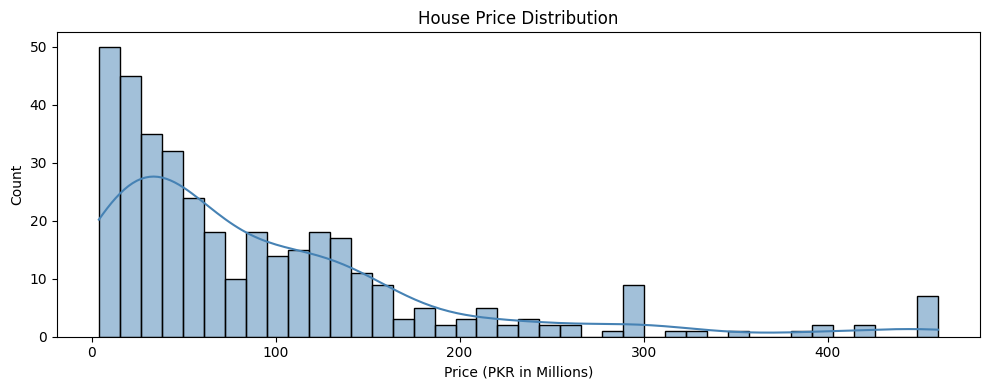

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(df['price'] / 1e6, bins=40, kde=True, color='steelblue')
plt.xlabel('Price (PKR in Millions)')
plt.ylabel('Count')
plt.title('House Price Distribution')
plt.tight_layout()
plt.show()

### Correlation Heatmap

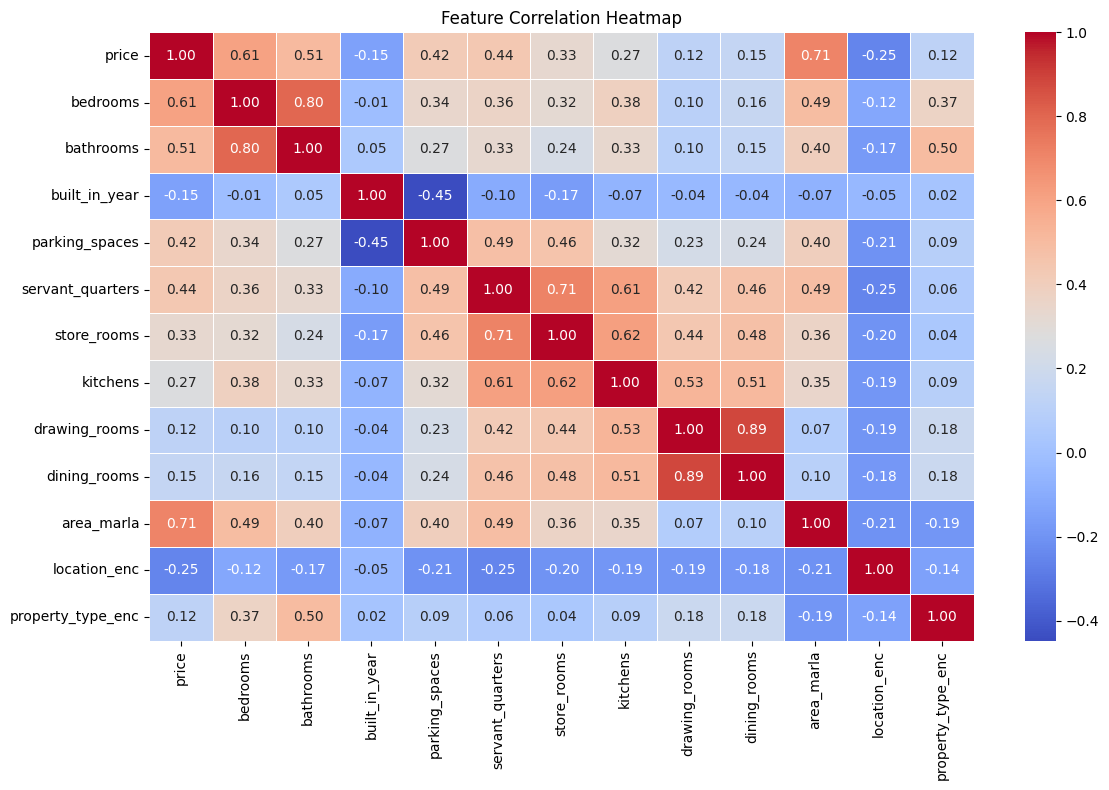

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Feature Selection

In [12]:
X_all = df.drop(columns=['price'])
y = df['price']

selector = SelectKBest(f_regression, k=8)
selector.fit(X_all, y)
selected_cols = X_all.columns[selector.get_support()].tolist()

print('Selected features after SelectKBest:')
for col in selected_cols:
    print(' -', col)

X = X_all[selected_cols]

Selected features after SelectKBest:
 - bedrooms
 - bathrooms
 - parking_spaces
 - servant_quarters
 - store_rooms
 - kitchens
 - area_marla
 - location_enc


## Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

Training samples: 294
Testing samples : 74


## Task 3 & 4 :- Model Training & Evaluation


In [14]:
models = [
    ('Linear Regression',  LinearRegression()),
    ('Decision Tree',      DecisionTreeRegressor(random_state=42)),
    ('Random Forest',      RandomForestRegressor(n_estimators=100, random_state=42)),
    ('Gradient Boosting',  GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ('XGBoost',            XGBRegressor(n_estimators=100, random_state=42, verbosity=0)),
    ('CatBoost',           CatBoostRegressor(iterations=100, random_seed=42, verbose=0)),
]

results = []
trained_models = {}

for name, model in models:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    mse  = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': round(mae, 2), 'MSE': round(mse, 2),
                    'RMSE': round(rmse, 2), 'R2 Score': round(r2, 4)})
    trained_models[name] = model
    print(f'{name} — R2: {r2:.4f}  RMSE: {rmse:,.0f}  MAE: {mae:,.0f}')

Linear Regression — R2: 0.6586  RMSE: 59,280,202  MAE: 35,696,510
Decision Tree — R2: 0.7774  RMSE: 47,871,804  MAE: 24,825,280
Random Forest — R2: 0.8257  RMSE: 42,355,500  MAE: 24,319,942
Gradient Boosting — R2: 0.8026  RMSE: 45,080,695  MAE: 24,321,197
XGBoost — R2: 0.7400  RMSE: 51,737,991  MAE: 28,604,114
CatBoost — R2: 0.8076  RMSE: 44,503,189  MAE: 26,344,664


## Model Comparison

In [15]:
results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
print('\n===== Model Performance Comparison =====')
print(results_df.to_string(index=False))



===== Model Performance Comparison =====
            Model         MAE          MSE        RMSE  R2 Score
    Random Forest 24319942.08 1.793988e+15 42355499.83    0.8257
         CatBoost 26344664.03 1.980534e+15 44503189.34    0.8076
Gradient Boosting 24321196.82 2.032269e+15 45080695.46    0.8026
    Decision Tree 24825279.92 2.291710e+15 47871804.01    0.7774
          XGBoost 28604114.23 2.676820e+15 51737990.76    0.7400
Linear Regression 35696510.44 3.514142e+15 59280202.31    0.6586


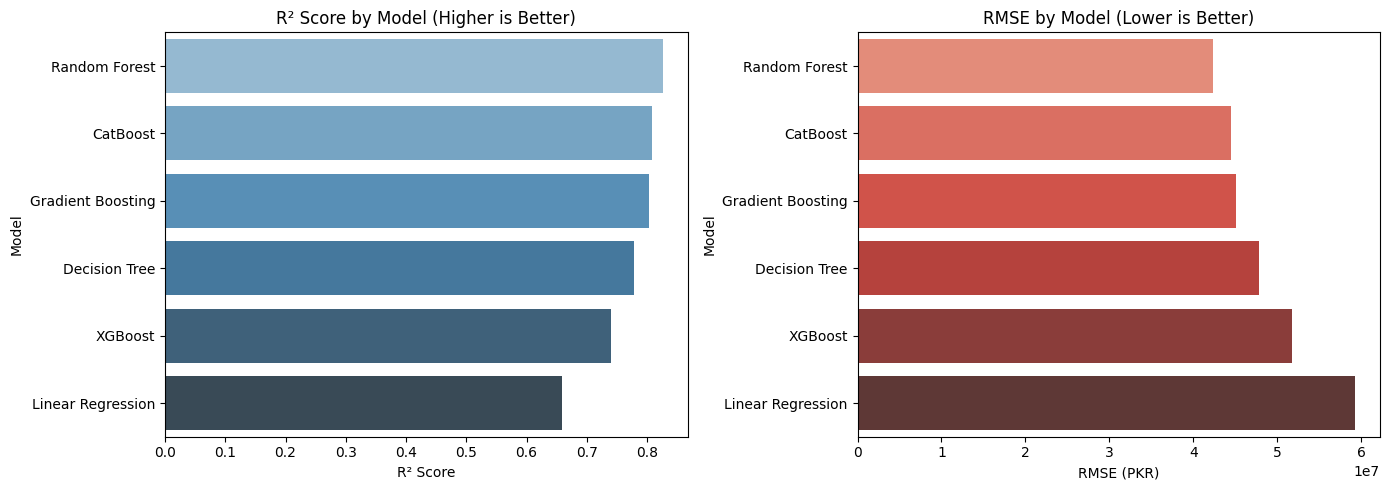

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='R2 Score', y='Model', palette='Blues_d', ax=axes[0])
axes[0].set_title('R² Score by Model (Higher is Better)')
axes[0].set_xlabel('R² Score')

sns.barplot(data=results_df.sort_values('RMSE'), x='RMSE', y='Model', palette='Reds_d', ax=axes[1])
axes[1].set_title('RMSE by Model (Lower is Better)')
axes[1].set_xlabel('RMSE (PKR)')

plt.tight_layout()
plt.show()

## Best Model

In [17]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f'Best Performing Model : {best_model_name}')
print(f'R2 Score              : {results_df.iloc[0]["R2 Score"]}')
print(f'RMSE                  : PKR {results_df.iloc[0]["RMSE"]:,.0f}')
print(f'MAE                   : PKR {results_df.iloc[0]["MAE"]:,.0f}')

Best Performing Model : Random Forest
R2 Score              : 0.8257
RMSE                  : PKR 42,355,500
MAE                   : PKR 24,319,942


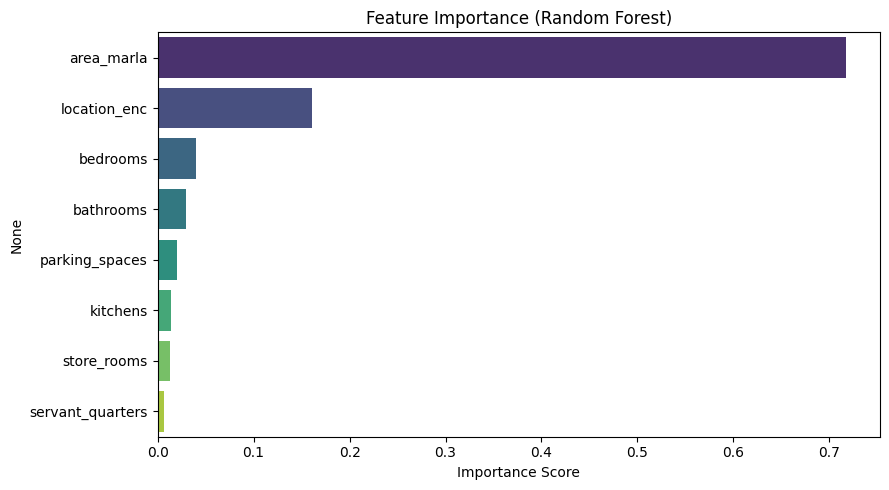


Feature Importance Scores:
area_marla          0.716902
location_enc        0.160663
bedrooms            0.039575
bathrooms           0.029483
parking_spaces      0.020484
kitchens            0.013889
store_rooms         0.012761
servant_quarters    0.006242
dtype: float64


In [18]:
rf_model = trained_models['Random Forest']
feature_importance = pd.Series(rf_model.feature_importances_, index=selected_cols).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nFeature Importance Scores:')
print(feature_importance)

## TASK 5 :House Price Prediction System


In [19]:
location_classes = list(le_location.classes_)
print('Available Locations:')
for i, loc in enumerate(location_classes):
    print(f'  [{i}] {loc}')

Available Locations:
  [0] Al-Ghurair Giga, DHA Defence Phase 2, DHA Defence, Islamabad, Islamabad Capital
  [1] Askari Tower 4, DHA Defence Phase 5, DHA Defence, Islamabad, Islamabad Capital
  [2] B-17, Islamabad, Islamabad Capital
  [3] Bahria Enclave - Sector A, Bahria Enclave, Bahria Town, Islamabad, Islamabad Capital
  [4] Bahria Enclave - Sector C, Bahria Enclave, Bahria Town, Islamabad, Islamabad Capital
  [5] Bahria Enclave - Sector C1, Bahria Enclave, Bahria Town, Islamabad, Islamabad Capital
  [6] Bahria Enclave - Sector C2, Bahria Enclave, Bahria Town, Islamabad, Islamabad Capital
  [7] Bahria Enclave - Sector H, Bahria Enclave, Bahria Town, Islamabad, Islamabad Capital
  [8] Bahria Enclave - Sector I, Bahria Enclave, Bahria Town, Islamabad, Islamabad Capital
  [9] Bahria Enclave - Sector J, Bahria Enclave, Bahria Town, Islamabad, Islamabad Capital
  [10] Bahria Enclave - Sector M, Bahria Enclave, Bahria Town, Islamabad, Islamabad Capital
  [11] Bahria Enclave - Sector N, Ba

In [20]:
def predict_house_price(area_marla, bedrooms, bathrooms, location):
    if location not in location_classes:
        print('Location not recognized. Run the cell above to see valid locations.')
        return None

    loc_enc = le_location.transform([location])[0]
    median_vals = X_train.median()

    input_dict = {col: median_vals[col] for col in selected_cols}
    input_dict['area_marla']   = area_marla
    input_dict['bedrooms']     = bedrooms
    input_dict['bathrooms']    = bathrooms
    if 'location_enc' in selected_cols:
        input_dict['location_enc'] = loc_enc

    input_df = pd.DataFrame([input_dict])[selected_cols]
    price = best_model.predict(input_df)[0]

    print('\n====== House Price Prediction ======')
    print(f'  Area           : {area_marla} Marla')
    print(f'  Bedrooms       : {bedrooms}')
    print(f'  Bathrooms      : {bathrooms}')
    print(f'  Location       : {location}')
    print(f'  Model Used     : {best_model_name}')
    print(f'  Estimated Price: PKR {price:,.0f}')
    print('====================================')
    return price

In [21]:
predict_house_price(
    area_marla = 10,
    bedrooms   = 4,
    bathrooms  = 3,
    location   = location_classes[10]
)


====== House Price Prediction ======
  Area           : 10 Marla
  Bedrooms       : 4
  Bathrooms      : 3
  Location       : Bahria Enclave - Sector M, Bahria Enclave, Bahria Town, Islamabad, Islamabad Capital
  Model Used     : Random Forest
  Estimated Price: PKR 56,232,000


np.float64(56232000.0)